# 🔬 Exploratory Data Analysis — Elliptic Bitcoin Dataset

**Goal:** Understand the dataset deeply before building the GNN fraud detection model.

**Dataset:** [Elliptic Bitcoin Transaction Dataset](https://www.kaggle.com/ellipticco/elliptic-data-set)
- ~203K Bitcoin transactions (nodes)
- ~234K directed edges (payment flows)
- 166 features per node (pre-normalized)
- Labels: **Illicit** (fraud), **Licit** (legit), **Unknown**

---

### Notebook Structure

| # | Section | Purpose |
|---|---------|--------|
| 1 | Imports & Config | Load libraries, set plot style |
| 2 | Load Raw Data | Read 3 CSVs, merge into one DataFrame |
| 3 | Dataset Overview | Shapes, dtypes, memory, missing values |
| 4 | Label Distribution | Bar chart — illicit vs licit vs unknown |
| 5 | Class Imbalance | Pie chart + ratio (labeled nodes only) |
| 6 | Feature Statistics | Describe all 166 features, NaN/Inf check |
| 7 | Feature Distributions | Histograms split by class |
| 8 | Correlation with Label | Top features correlated with fraud |
| 9 | Correlation Heatmap | Inter-feature correlations |
| 10 | Graph Degree Distribution | In/out/total degree histograms |
| 11 | Temporal Analysis | Fraud rate per timestep |
| 12 | Feature Variance | High vs low variance features |
| 13 | Pairwise Scatter | Top features colored by class |
| 14 | Box Plots by Class | Distribution comparison |
| 15 | Key Takeaways | Summary of findings + model implications |

---
## 1. Imports & Config

**What:** Load all necessary libraries and configure plot aesthetics.

**Libraries used:**
- `pandas` — data loading and manipulation
- `numpy` — numerical operations
- `matplotlib` + `seaborn` — visualization

**Note:** We use `darkgrid` seaborn style and a custom 3-color palette for consistency across all plots.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Config
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.1)
PALETTE = {"Illicit": "#e74c3c", "Licit": "#2ecc71", "Unknown": "#95a5a6"}

RAW_DIR  = "../data/raw"
PLOT_DIR = "../results/plots/eda"
os.makedirs(PLOT_DIR, exist_ok=True)

print("✅ Imports loaded")

✅ Imports loaded


---
## 2. Load Raw Data

**What:** Read the 3 raw CSV files and merge them into a single DataFrame.

**Files:**

| File | Header? | Columns | Rows |
|------|---------|---------|------|
| `elliptic_txs_features.csv` | ❌ No header | col 0 = txId, cols 1–166 = features | 203,769 |
| `elliptic_txs_edgelist.csv` | ✅ Has header | txId1, txId2 | 234,355 |
| `elliptic_txs_classes.csv` | ✅ Has header | txId, class | 203,769 |

**Label mapping:**
- `"1"` → `1` (illicit / fraud)
- `"2"` → `0` (licit / legit)
- `"unknown"` → `-1` (unlabeled)

**Expected output:** Merged DataFrame of shape `(203769, 168)` — 1 txId + 166 features + 1 label

In [2]:
# ── Features (no header: col 0 = txId, col 1 = timestep, cols 2-166 = features)
features = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_features.csv"), header=None)
col_names = ["txId"] + [f"feat_{i}" for i in range(1, 167)]
features.columns = col_names

# ── Edgelist (has header: txId1, txId2)
edges = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_edgelist.csv"))

# ── Classes (has header: txId, class)
classes = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_classes.csv"))

# Map labels: "1" -> 1 (illicit), "2" -> 0 (licit), "unknown" -> -1
label_map = {"1": 1, "2": 0, "unknown": -1}
classes["label"] = classes["class"].astype(str).map(label_map)

# Merge features + labels into one DataFrame
df = features.merge(classes[["txId", "label"]], on="txId", how="left")
df["label"] = df["label"].fillna(-1).astype(int)

print(f"Features shape : {features.shape}")
print(f"Edges shape    : {edges.shape}")
print(f"Classes shape  : {classes.shape}")
print(f"Merged shape   : {df.shape}")

Features shape : (203769, 167)
Edges shape    : (234355, 2)
Classes shape  : (203769, 3)
Merged shape   : (203769, 168)


---
## 3. Dataset Overview

**What:** Print key statistics about the dataset — dimensions, memory, missing values, timestep range.

**What to look for:**
- Any **missing values** or **infinities** in the features?
- How many **timesteps** does the dataset span?
- How much **memory** does the full dataset consume?

In [3]:
feature_cols = [c for c in df.columns if c.startswith("feat_")]
mem_mb = df.memory_usage(deep=True).sum() / 1e6

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Transactions (nodes)   : {len(df):,}")
print(f"  Edges (directed)       : {len(edges):,}")
print(f"  Features per node      : {len(feature_cols)}")
print(f"  Memory usage           : {mem_mb:.1f} MB")
print(f"  Missing values         : {df[feature_cols].isna().sum().sum()}")
print(f"  Inf values             : {np.isinf(df[feature_cols].values).sum()}")
print(f"  Timesteps (feat_1)     : {df['feat_1'].nunique()}")
print(f"  Timestep range         : {df['feat_1'].min():.0f} – {df['feat_1'].max():.0f}")
print()
print("First 5 rows:")
df[["txId", "feat_1", "feat_2", "feat_3", "feat_4", "feat_5", "label"]].head()

  DATASET OVERVIEW
  Transactions (nodes)   : 203,769
  Edges (directed)       : 234,355
  Features per node      : 166
  Memory usage           : 273.9 MB
  Missing values         : 0
  Inf values             : 0
  Timesteps (feat_1)     : 49
  Timestep range         : 1 – 49

First 5 rows:


,txId,feat_1,feat_2,feat_3,feat_4,feat_5,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-1
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-1
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,-1


---
## 4. Label Distribution

**What:** Visualize how many nodes fall into each label category.

**Why this matters:**
- Shows the **proportion of labeled vs unlabeled** data
- Reveals how much training data we actually have
- The large "Unknown" segment means we're in a **semi-supervised** setting

**Expected breakdown:**
- Unknown: ~77% → these nodes have no label, but GNNs can still use their features + edges
- Licit: ~21% → legitimate transactions
- Illicit: ~2% → fraudulent transactions (our target class)

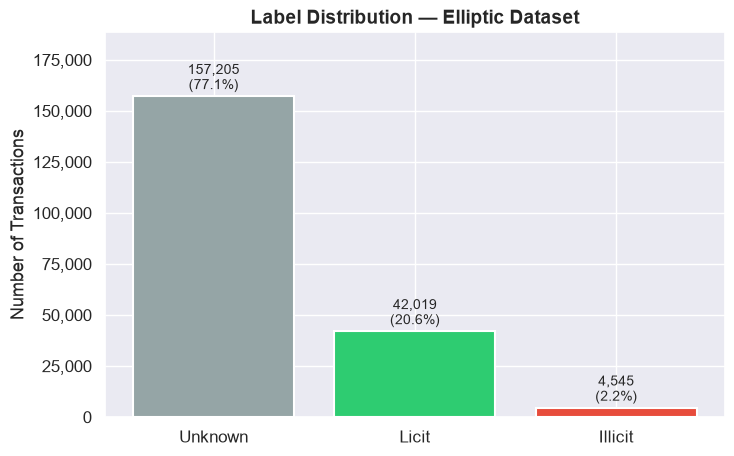


Illicit : 4,545  (2.2%)
Licit   : 42,019  (20.6%)
Unknown : 157,205  (77.1%)


In [4]:
counts = df["label"].value_counts().sort_index()
names  = {-1: "Unknown", 0: "Licit", 1: "Illicit"}
labels = [names[v] for v in counts.index]
colors = [PALETTE[n] for n in labels]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.5)

# Annotate
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_title("Label Distribution — Elliptic Dataset", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, max(counts.values) * 1.2)
fig.savefig(f"{PLOT_DIR}/01_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nIllicit : {counts.get(1, 0):,}  ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"Licit   : {counts.get(0, 0):,}  ({counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"Unknown : {counts.get(-1, 0):,}  ({counts.get(-1, 0)/len(df)*100:.1f}%)")

---
## 5. Class Imbalance Analysis

**What:** Focus on **labeled nodes only** and measure the imbalance between illicit and licit.

**Why this matters:**
- If the classes are imbalanced (and they are — ~9:1), a naive model can get ~90% accuracy by always predicting "Licit"
- We need to compute the **imbalance ratio** to set up `class_weight` in our loss function
- The ratio directly feeds into `CrossEntropyLoss(weight=[1.0, ratio])`

**What to look for:**
- The pie chart shows % split between the two classes
- The bar chart shows absolute counts for intuition

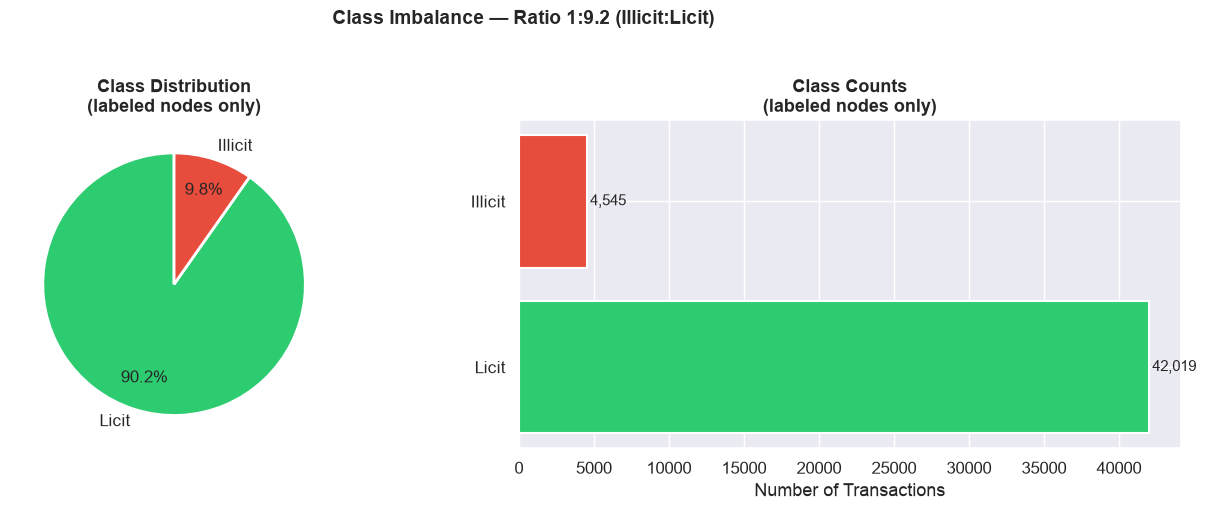


Labeled nodes    : 46,564
Imbalance ratio  : 1 : 9.2  (illicit : licit)


In [5]:
labeled = df[df["label"] != -1]
lbl_counts = labeled["label"].value_counts().sort_index()
lbl_names  = {0: "Licit", 1: "Illicit"}
lbl_labels = [lbl_names[v] for v in lbl_counts.index]
lbl_colors = [PALETTE[n] for n in lbl_labels]

ratio = lbl_counts.get(0, 0) / max(lbl_counts.get(1, 1), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(lbl_counts.values, labels=lbl_labels, colors=lbl_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
            pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Class Distribution\n(labeled nodes only)", fontsize=13, fontweight="bold")

# Horizontal bar
axes[1].barh(lbl_labels, lbl_counts.values, color=lbl_colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Class Counts\n(labeled nodes only)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Transactions")
for i, (name, count) in enumerate(zip(lbl_labels, lbl_counts.values)):
    axes[1].text(count + 200, i, f"{count:,}", va="center", fontsize=11)

fig.suptitle(f"Class Imbalance — Ratio 1:{ratio:.1f} (Illicit:Licit)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/02_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLabeled nodes    : {len(labeled):,}")
print(f"Imbalance ratio  : 1 : {ratio:.1f}  (illicit : licit)")

---
## 6. Feature Statistics

**What:** Compute summary statistics for all 166 features and check data quality.

**Key checks:**
- **NaN values** — any missing data that needs imputation?
- **Inf values** — any infinities that could crash training?
- **Zero-dominated features** — features that are mostly zeros may be uninformative
- **Value ranges** — are features pre-normalized?

**What to look for in the plot:**
- The "Mean ± Std" ribbon shows the typical range of each feature
- If features are pre-normalized, means should be ~0 and stds ~1
- `feat_1` (timestep) will be an outlier with much higher variance

Summary statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max
feat_1,203769.0,2.384396e+01,15.172170,1.000000,9.000000,23.000000,38.000000,49.000000
feat_2,203769.0,2.231681e-17,1.000002,-0.172983,-0.172532,-0.169204,-0.131855,71.681966
feat_3,203769.0,1.785345e-17,1.000002,-0.210553,-0.180327,-0.132897,-0.055242,73.595052
feat_4,203769.0,3.570689e-17,1.000002,-1.756361,-1.201369,0.463609,1.018602,2.683580
feat_5,203769.0,6.890314e-17,1.000002,-0.121970,-0.121970,-0.121970,-0.121970,49.027598
feat_6,203769.0,7.755091e-17,1.000002,-0.063725,-0.043875,-0.043875,-0.043875,260.090707
feat_7,203769.0,5.746578e-17,1.000002,-0.113002,-0.113002,-0.113002,-0.113002,54.565178
feat_8,203769.0,2.566433e-17,1.000002,-0.061584,-0.061584,-0.061584,-0.061584,113.440873
feat_9,203769.0,2.901185e-17,1.000002,-0.163646,-0.163517,-0.162044,-0.135593,73.354565
feat_10,203769.0,4.463361e-17,1.000002,-0.169460,-0.169070,-0.166226,-0.132366,72.318396



Features with NaN      : 0
Features >50% zeros    : 0
Features >90% zeros    : 0


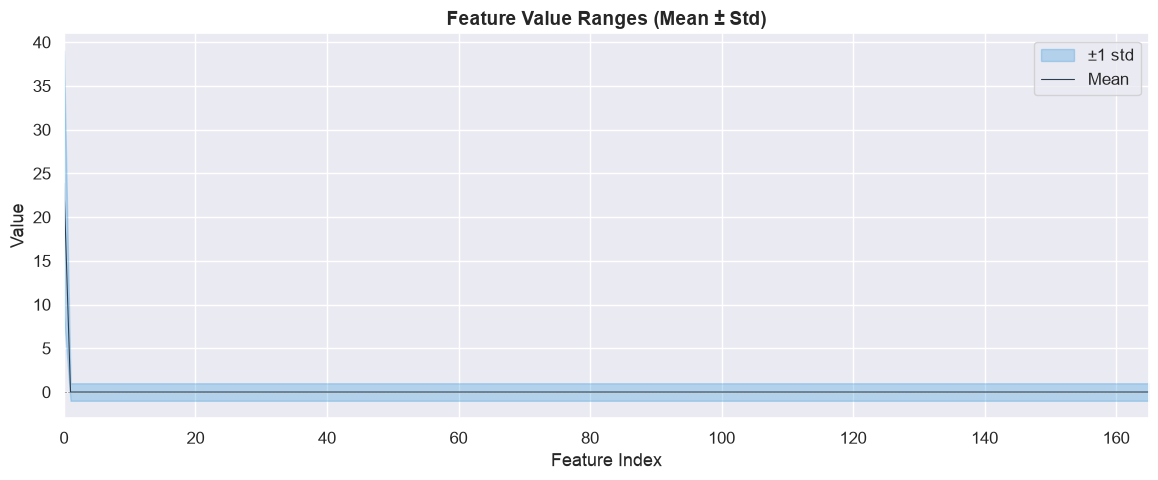

In [6]:
desc = df[feature_cols].describe().T

print("Summary statistics (first 10 features):")
display(desc.head(10))

# Check for problematic values
nan_counts = df[feature_cols].isna().sum()
zero_frac  = (df[feature_cols] == 0).mean()

print(f"\nFeatures with NaN      : {(nan_counts > 0).sum()}")
print(f"Features >50% zeros    : {(zero_frac > 0.5).sum()}")
print(f"Features >90% zeros    : {(zero_frac > 0.9).sum()}")

# Plot feature value ranges (mean +/- std)
fig, ax = plt.subplots(figsize=(14, 5))
means = desc["mean"].values
stds  = desc["std"].values
x     = np.arange(len(feature_cols))

ax.fill_between(x, means - stds, means + stds, alpha=0.3, color="#3498db", label="±1 std")
ax.plot(x, means, color="#2c3e50", linewidth=0.8, label="Mean")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_title("Feature Value Ranges (Mean ± Std)", fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Value")
ax.legend()
ax.set_xlim(0, len(feature_cols) - 1)
fig.savefig(f"{PLOT_DIR}/03_feature_ranges.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Feature Distributions by Class

**What:** Plot histograms of selected features, split by illicit vs licit class.

**Why this matters:**
- If a feature's distribution **differs significantly** between classes, it's a useful predictor
- Features where the two distributions overlap heavily are less discriminative on their own
- We pick 8 features spread across the index range to sample both **local features** (2–94) and **aggregated features** (95–166)

**What to look for:**
- Features where the red (Illicit) and green (Licit) histograms are **separated** → strong signal
- Features where they **overlap completely** → weak signal on its own

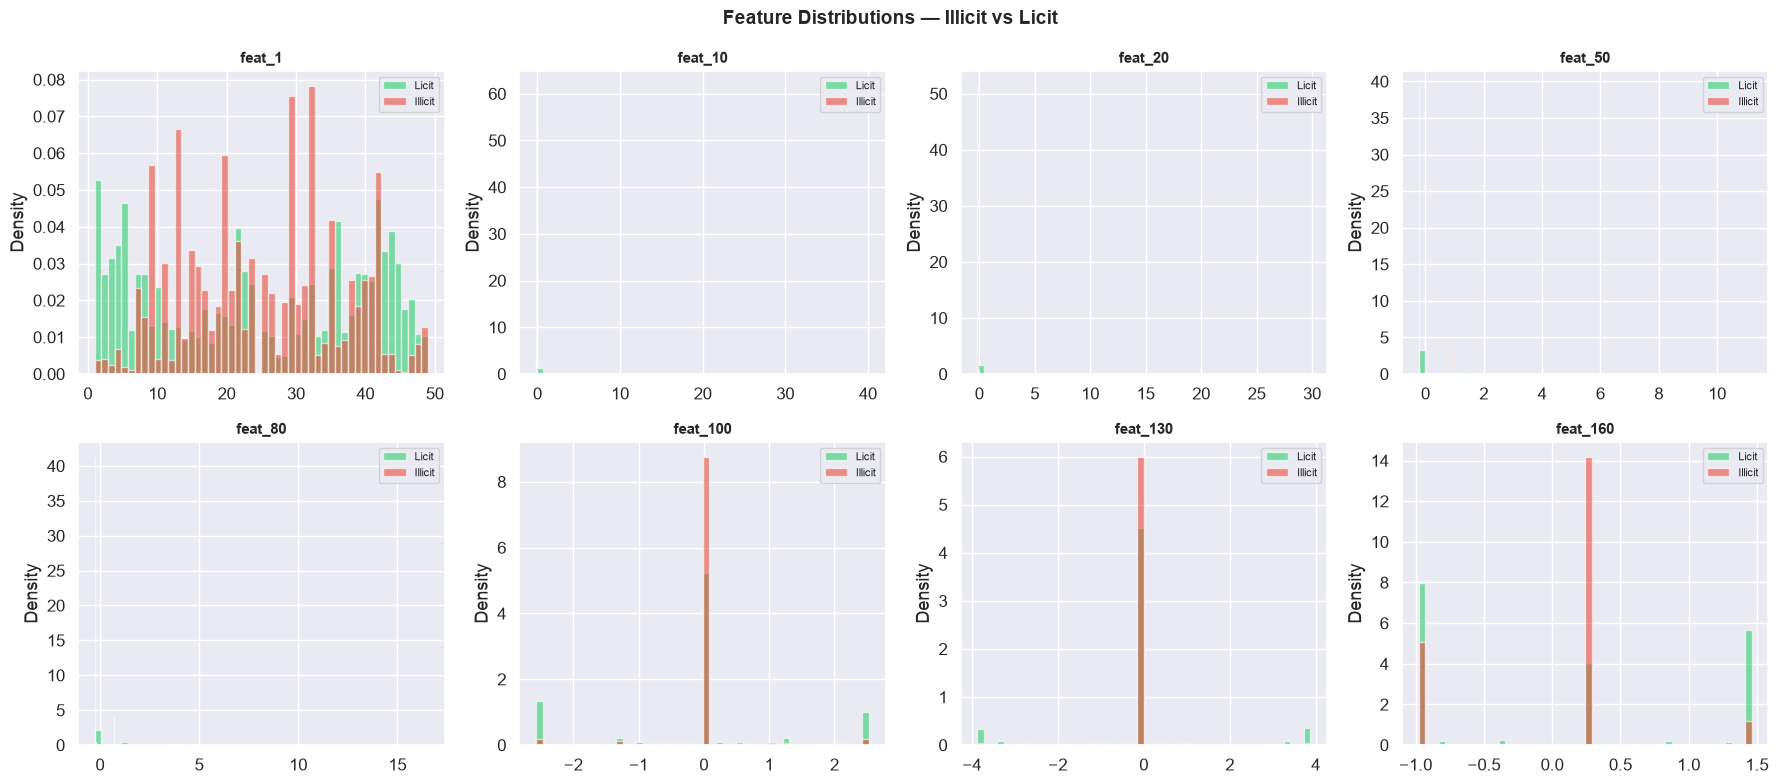

In [7]:
labeled_df = df[df["label"] != -1].copy()
labeled_df["class_name"] = labeled_df["label"].map({1: "Illicit", 0: "Licit"})

# Pick 8 features spread across the range
selected = ["feat_1", "feat_10", "feat_20", "feat_50", "feat_80", "feat_100", "feat_130", "feat_160"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(selected):
    ax = axes[i]
    for cls, color in [("Licit", PALETTE["Licit"]), ("Illicit", PALETTE["Illicit"])]:
        vals = labeled_df.loc[labeled_df["class_name"] == cls, feat]
        ax.hist(vals, bins=50, alpha=0.6, color=color, label=cls, density=True)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

fig.suptitle("Feature Distributions — Illicit vs Licit", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/04_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Top Features Correlated with Fraud Label

**What:** Compute the absolute Pearson correlation between each feature and the binary label, then rank them.

**Why this matters:**
- Identifies which individual features carry the most **signal** for fraud detection
- If the max correlation is low (e.g., < 0.3), it means **no single feature is sufficient** — we need feature combinations and graph structure (motivating the GNN)
- These top features will also be used for scatter plots and heatmaps below

**What to look for:**
- Which features are in the top 10? Are they **local** (feat 2–94) or **aggregated** (feat 95–166)?
- Is the max |r| above 0.3? Above 0.5?

Top 15 features most correlated with fraud label:

   1.    feat_54  |r| = 0.2615
   2.    feat_90  |r| = 0.2276
   3.    feat_56  |r| = 0.2271
   4.    feat_91  |r| = 0.2213
   5.   feat_143  |r| = 0.1919
   6.   feat_151  |r| = 0.1872
   7.    feat_92  |r| = 0.1858
   8.    feat_53  |r| = 0.1718
   9.   feat_155  |r| = 0.1530
  10.    feat_55  |r| = 0.1421
  11.   feat_115  |r| = 0.1376
  12.   feat_149  |r| = 0.1359
  13.   feat_157  |r| = 0.1352
  14.    feat_84  |r| = 0.1234
  15.    feat_86  |r| = 0.1191


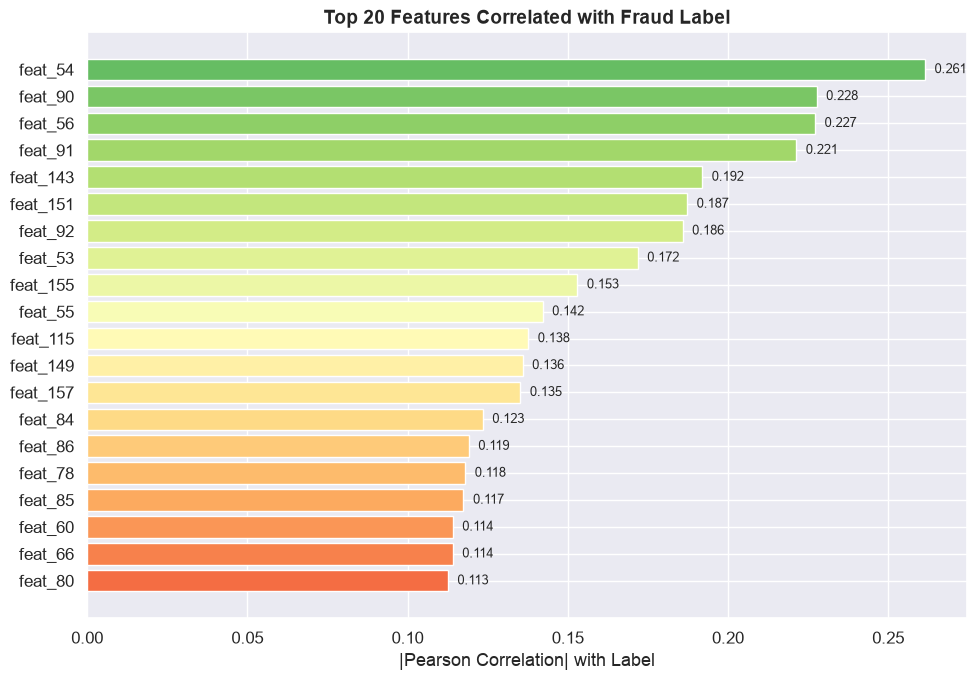

In [8]:
corr = labeled_df[feature_cols + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=False)

print("Top 15 features most correlated with fraud label:\n")
for rank, (feat, val) in enumerate(corr.head(15).items(), 1):
    print(f"  {rank:2d}. {feat:>10s}  |r| = {val:.4f}")

# Plot top 20
top_n = 20
top_corr = corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n))
ax.barh(range(top_n), top_corr.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_corr.index[::-1])
ax.set_xlabel("|Pearson Correlation| with Label")
ax.set_title(f"Top {top_n} Features Correlated with Fraud Label", fontsize=14, fontweight="bold")

for bar_idx, val in enumerate(top_corr.values[::-1]):
    ax.text(val + 0.003, bar_idx, f"{val:.3f}", va="center", fontsize=9)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/05_correlation_with_label.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Correlation Heatmap (Top Features)

**What:** Show pairwise Pearson correlations among the top 15 label-correlated features.

**Why this matters:**
- If top features are **highly correlated with each other**, they carry redundant information
- High inter-feature correlation (multicollinearity) is fine for GNNs but can hurt linear models
- Helps identify **feature groups** that capture similar signals

**What to look for:**
- Dark red clusters → groups of correlated features (e.g., aggregated features often correlate)
- Blue cells → negatively correlated pairs
- Features with low inter-correlation but high label-correlation are the most valuable

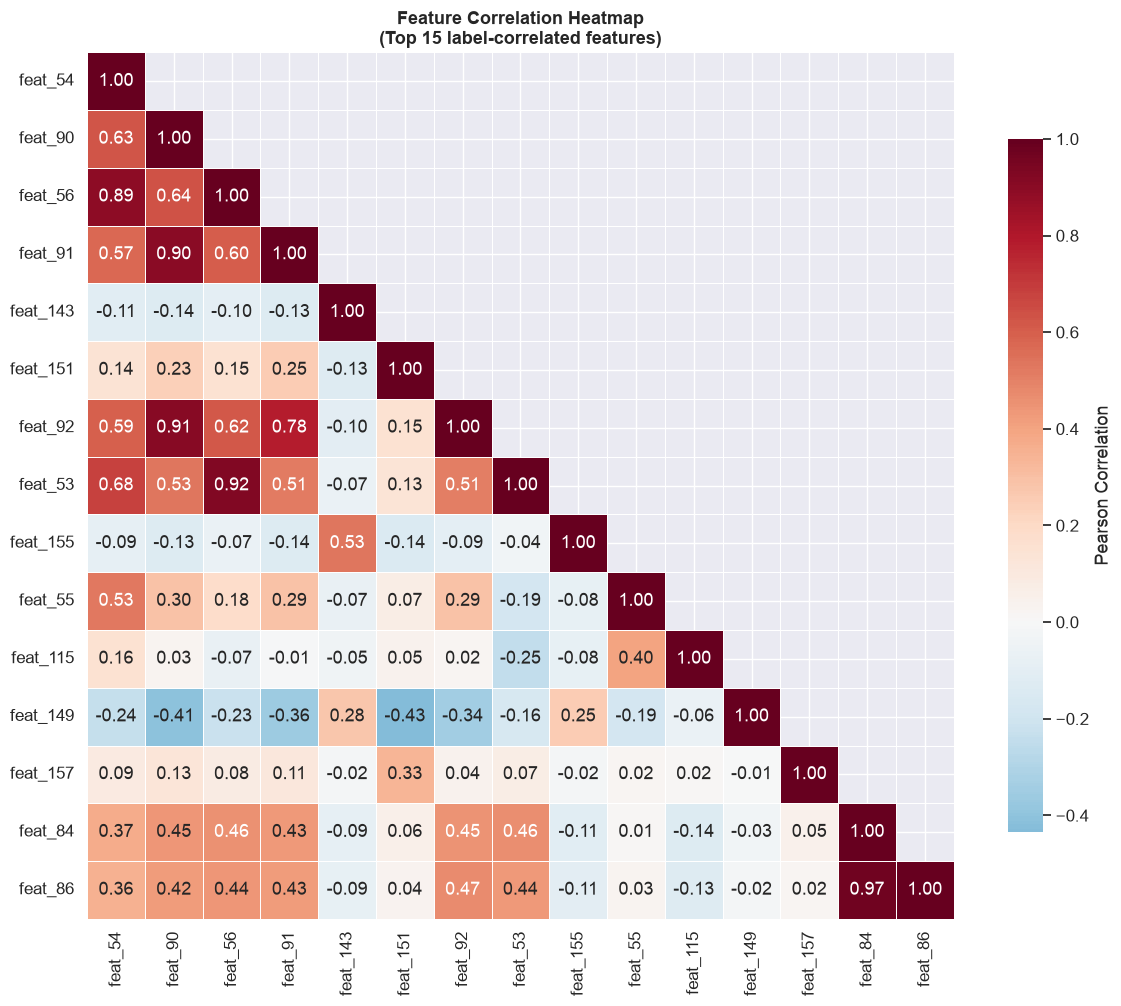

In [9]:
top_feats = corr.head(15).index.tolist()
corr_matrix = labeled_df[top_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
ax.set_title("Feature Correlation Heatmap\n(Top 15 label-correlated features)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/10_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Graph Degree Distribution

**What:** Analyze the connectivity of the transaction graph — how many edges does each node have?

**Definitions:**
- **Out-degree** = number of outgoing edges (transactions this node sent money to)
- **In-degree** = number of incoming edges (transactions that sent money to this node)
- **Total degree** = in-degree + out-degree

**Why this matters for GNNs:**
- GNNs aggregate information from **neighbors** — nodes with more neighbors get richer representations
- **Isolated nodes** (degree 0) cannot benefit from message passing at all
- **Hub nodes** (very high degree) may dominate aggregation — GraphSAGE's neighbor sampling helps
- A **heavy-tailed** distribution is common in financial networks

**What to look for:**
- Are there isolated nodes? (If yes, GNN won't help for those)
- Is the distribution heavy-tailed? (Log-scale y-axis reveals this)
- What's the max degree? (Extreme hubs?)

Isolated nodes (deg=0) : 0
Mean degree            : 2.30
Median degree          : 2
Max degree             : 473
Mean out-degree        : 1.41
Mean in-degree         : 1.58


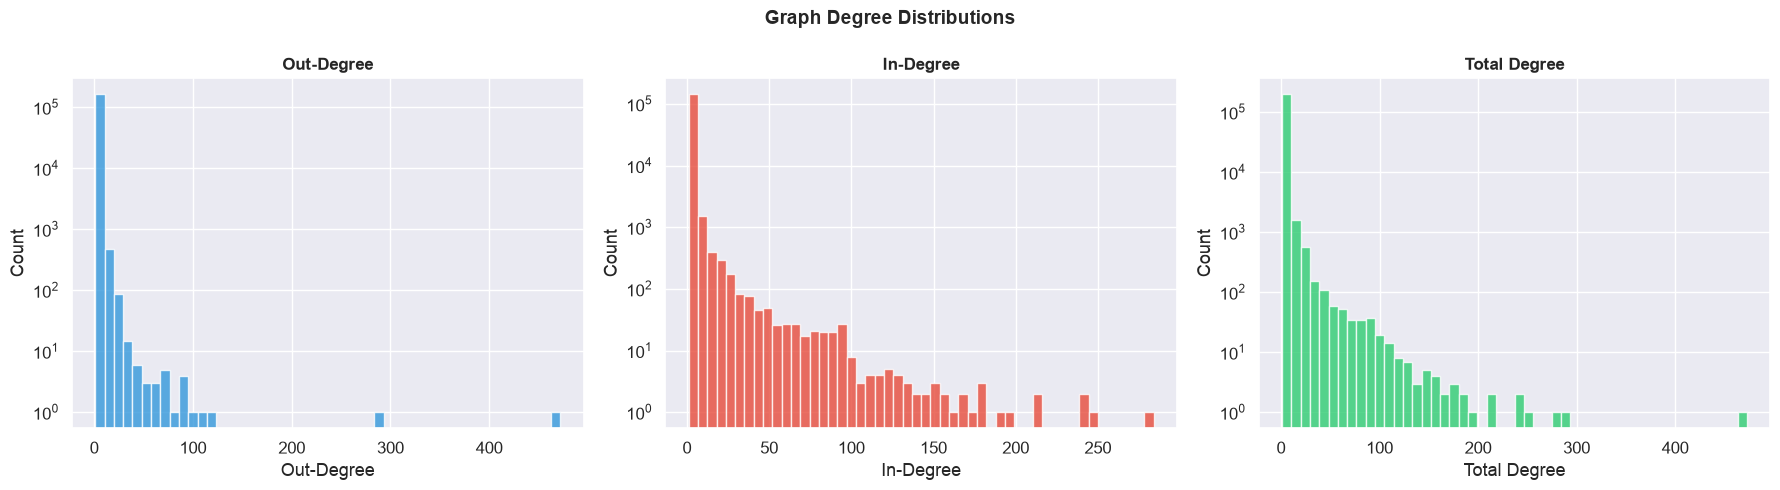

In [10]:
out_deg = edges["txId1"].value_counts()
in_deg  = edges["txId2"].value_counts()

# Total degree
all_tx = set(df["txId"].values)
total_deg = pd.Series(0, index=list(all_tx))
for tx in out_deg.index:
    if tx in all_tx:
        total_deg[tx] += out_deg[tx]
for tx in in_deg.index:
    if tx in all_tx:
        total_deg[tx] += in_deg[tx]

print(f"Isolated nodes (deg=0) : {(total_deg == 0).sum():,}")
print(f"Mean degree            : {total_deg.mean():.2f}")
print(f"Median degree          : {total_deg.median():.0f}")
print(f"Max degree             : {total_deg.max()}")
print(f"Mean out-degree        : {out_deg.mean():.2f}")
print(f"Mean in-degree         : {in_deg.mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(out_deg.values, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("Out-Degree", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Out-Degree"); axes[0].set_ylabel("Count"); axes[0].set_yscale("log")

axes[1].hist(in_deg.values, bins=50, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1].set_title("In-Degree", fontsize=12, fontweight="bold")
axes[1].set_xlabel("In-Degree"); axes[1].set_ylabel("Count"); axes[1].set_yscale("log")

axes[2].hist(total_deg.values, bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[2].set_title("Total Degree", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Total Degree"); axes[2].set_ylabel("Count"); axes[2].set_yscale("log")

fig.suptitle("Graph Degree Distributions", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/06_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Temporal Analysis — Fraud Rate per Timestep

**What:** The Elliptic dataset spans **49 timesteps** (biweekly snapshots). `feat_1` is the timestep index. We analyze how fraud activity varies over time.

**Why this matters:**
- If fraud rate varies dramatically across timesteps, our **train/test split strategy** matters a lot
- **Chronological splits** (train on early timesteps, test on later) simulate real deployment and are more rigorous than random splits
- Sudden spikes in fraud rate may indicate **coordinated attacks** or **reporting artifacts**

**Plots generated:**
1. Total nodes per timestep (including unknown)
2. Labeled nodes per timestep (stacked: licit + illicit)
3. Fraud rate (%) per timestep with mean line
4. Raw illicit count per timestep

Number of timesteps  : 49
Avg fraud rate       : 11.3%
Max fraud rate       : 36.0% (timestep 13)
Min fraud rate       : 0.3% (timestep 46)


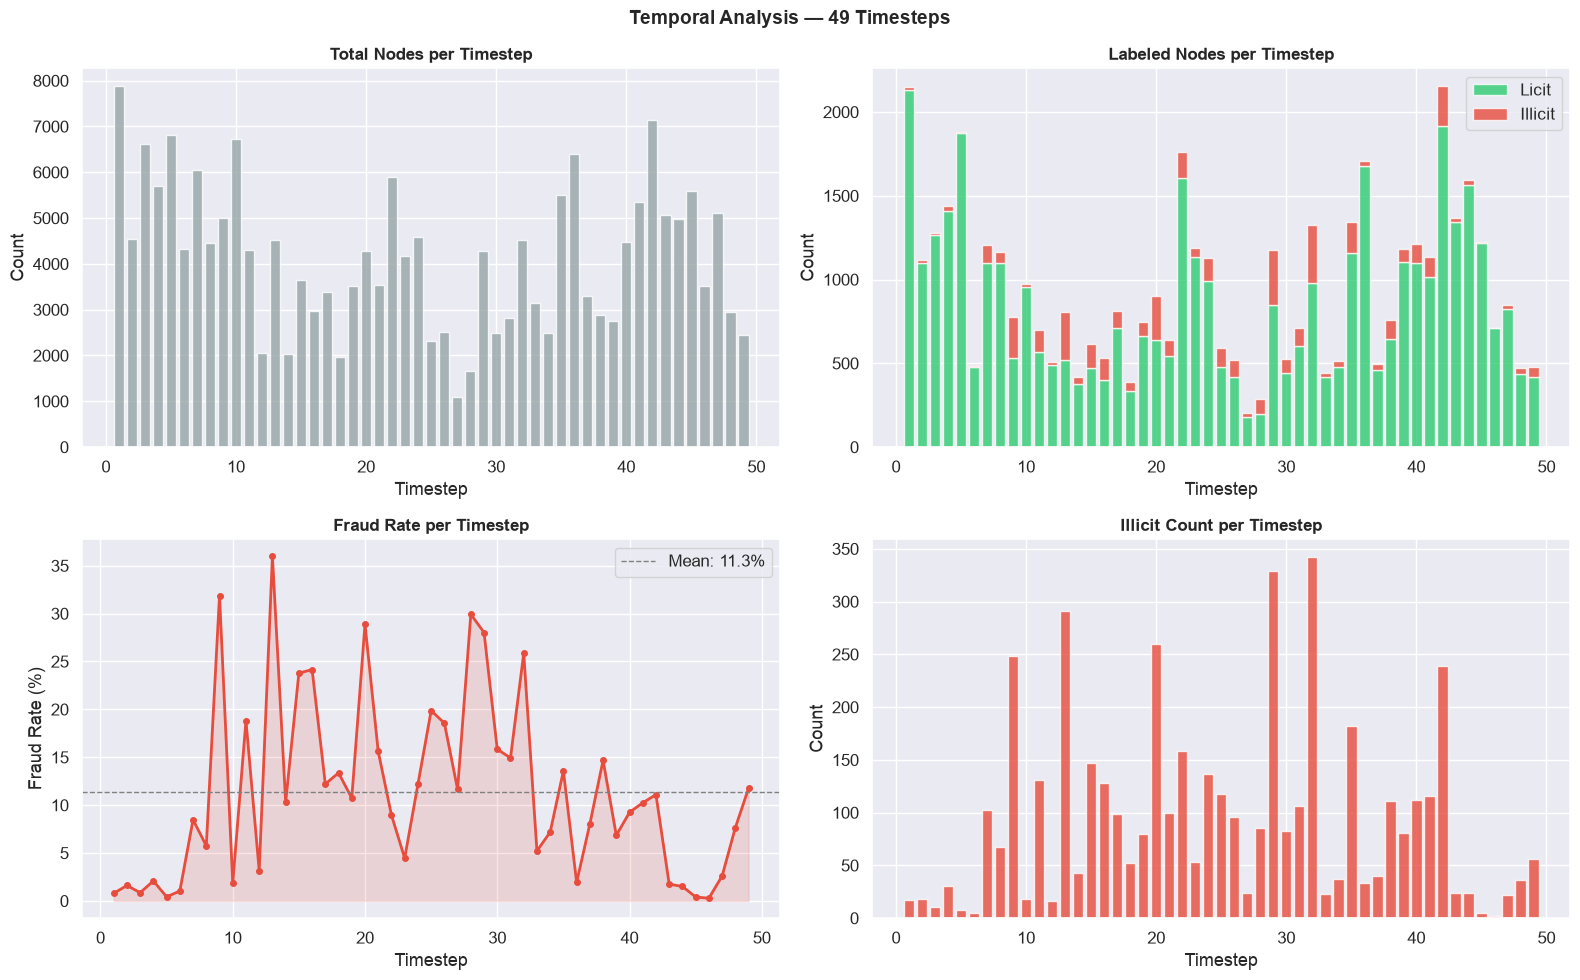

In [11]:
df_temp = df.copy()
df_temp["timestep"] = df_temp["feat_1"].astype(int)
labeled_temp = df_temp[df_temp["label"] != -1]

ts_stats = labeled_temp.groupby("timestep").agg(
    total=("label", "count"),
    illicit=("label", "sum"),
)
ts_stats["licit"]      = ts_stats["total"] - ts_stats["illicit"]
ts_stats["fraud_rate"] = ts_stats["illicit"] / ts_stats["total"] * 100

all_ts = df_temp.groupby("timestep").size()

print(f"Number of timesteps  : {len(ts_stats)}")
print(f"Avg fraud rate       : {ts_stats['fraud_rate'].mean():.1f}%")
print(f"Max fraud rate       : {ts_stats['fraud_rate'].max():.1f}% (timestep {ts_stats['fraud_rate'].idxmax()})")
print(f"Min fraud rate       : {ts_stats['fraud_rate'].min():.1f}% (timestep {ts_stats['fraud_rate'].idxmin()})")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total nodes per timestep
axes[0, 0].bar(all_ts.index, all_ts.values, color="#95a5a6", edgecolor="white", alpha=0.8)
axes[0, 0].set_title("Total Nodes per Timestep", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Timestep"); axes[0, 0].set_ylabel("Count")

# Stacked labeled nodes
axes[0, 1].bar(ts_stats.index, ts_stats["licit"], color=PALETTE["Licit"],
               label="Licit", edgecolor="white", alpha=0.8)
axes[0, 1].bar(ts_stats.index, ts_stats["illicit"], bottom=ts_stats["licit"],
               color=PALETTE["Illicit"], label="Illicit", edgecolor="white", alpha=0.8)
axes[0, 1].set_title("Labeled Nodes per Timestep", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Timestep"); axes[0, 1].set_ylabel("Count"); axes[0, 1].legend()

# Fraud rate line
axes[1, 0].plot(ts_stats.index, ts_stats["fraud_rate"], color="#e74c3c",
                linewidth=2, marker="o", markersize=4)
axes[1, 0].axhline(ts_stats["fraud_rate"].mean(), color="gray", linestyle="--",
                   linewidth=1, label=f"Mean: {ts_stats['fraud_rate'].mean():.1f}%")
axes[1, 0].fill_between(ts_stats.index, ts_stats["fraud_rate"], alpha=0.15, color="#e74c3c")
axes[1, 0].set_title("Fraud Rate per Timestep", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Timestep"); axes[1, 0].set_ylabel("Fraud Rate (%)"); axes[1, 0].legend()

# Illicit count
axes[1, 1].bar(ts_stats.index, ts_stats["illicit"], color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1, 1].set_title("Illicit Count per Timestep", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Timestep"); axes[1, 1].set_ylabel("Count")

fig.suptitle("Temporal Analysis — 49 Timesteps", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/07_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Feature Variance Ranking

**What:** Rank all 166 features by their variance to identify high-signal vs near-constant features.

**Why this matters:**
- **Low-variance features** carry little information and could be dropped to reduce dimensionality
- **High-variance features** (beyond `feat_1`) may capture important patterns
- Since the Elliptic features are pre-normalized, most variances should be ~1.0

**What to look for:**
- `feat_1` (timestep) will have much higher variance (~230) since it ranges 1–49
- All other features should cluster around variance = 1.0

Top 10 highest-variance features:
      feat_1: 230.1947
     feat_71: 1.0000
     feat_16: 1.0000
     feat_81: 1.0000
     feat_11: 1.0000
     feat_22: 1.0000
     feat_63: 1.0000
    feat_142: 1.0000
    feat_126: 1.0000
    feat_161: 1.0000

Top 10 lowest-variance features:
    feat_124: 1.000005
    feat_147: 1.000005
     feat_45: 1.000005
    feat_125: 1.000005
    feat_109: 1.000005
     feat_93: 1.000005
     feat_77: 1.000005
    feat_154: 1.000005
    feat_148: 1.000005
     feat_64: 1.000005


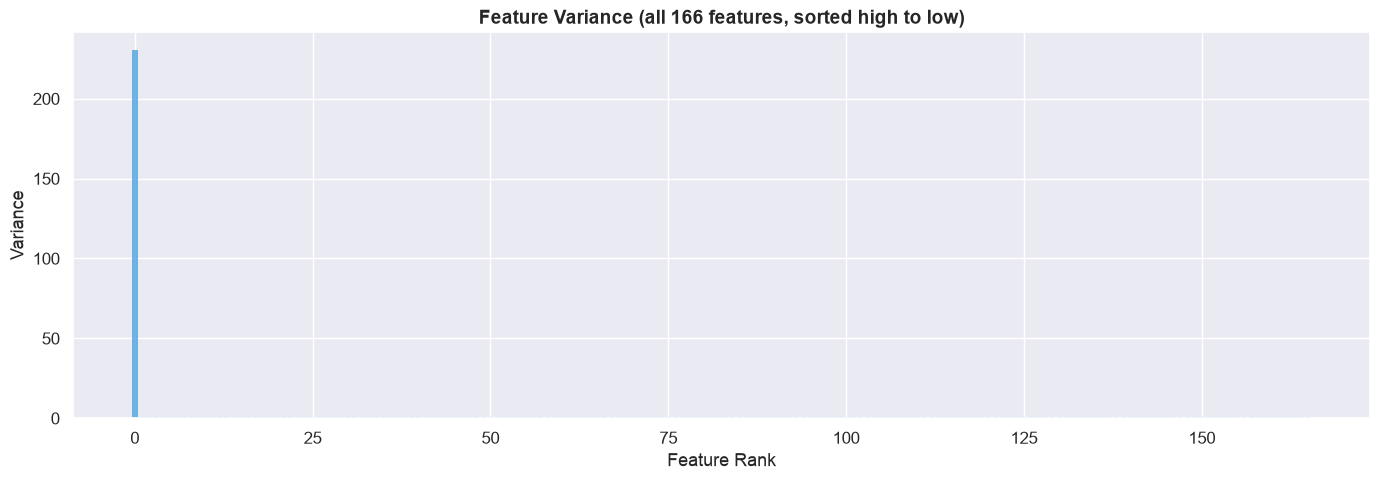

In [12]:
variances = df[feature_cols].var().sort_values(ascending=False)

print("Top 10 highest-variance features:")
for feat, val in variances.head(10).items():
    print(f"  {feat:>10s}: {val:.4f}")

print("\nTop 10 lowest-variance features:")
for feat, val in variances.tail(10).items():
    print(f"  {feat:>10s}: {val:.6f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(variances)), variances.values, color="#3498db", alpha=0.7, edgecolor="none")
ax.set_title("Feature Variance (all 166 features, sorted high to low)", fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Variance")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/08_feature_variance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 13. Pairwise Scatter — Top Correlated Features

**What:** Scatter plot pairs of the top 6 most label-correlated features, colored by class.

**Why this matters:**
- Shows whether **pairwise combinations** of features create separable clusters
- If illicit (red) and licit (green) points form distinct clusters in 2D, even simple classifiers may work
- Heavy overlap confirms we need more sophisticated models (GNNs)

**Note:** We sample 5,000 labeled nodes to avoid overplotting.

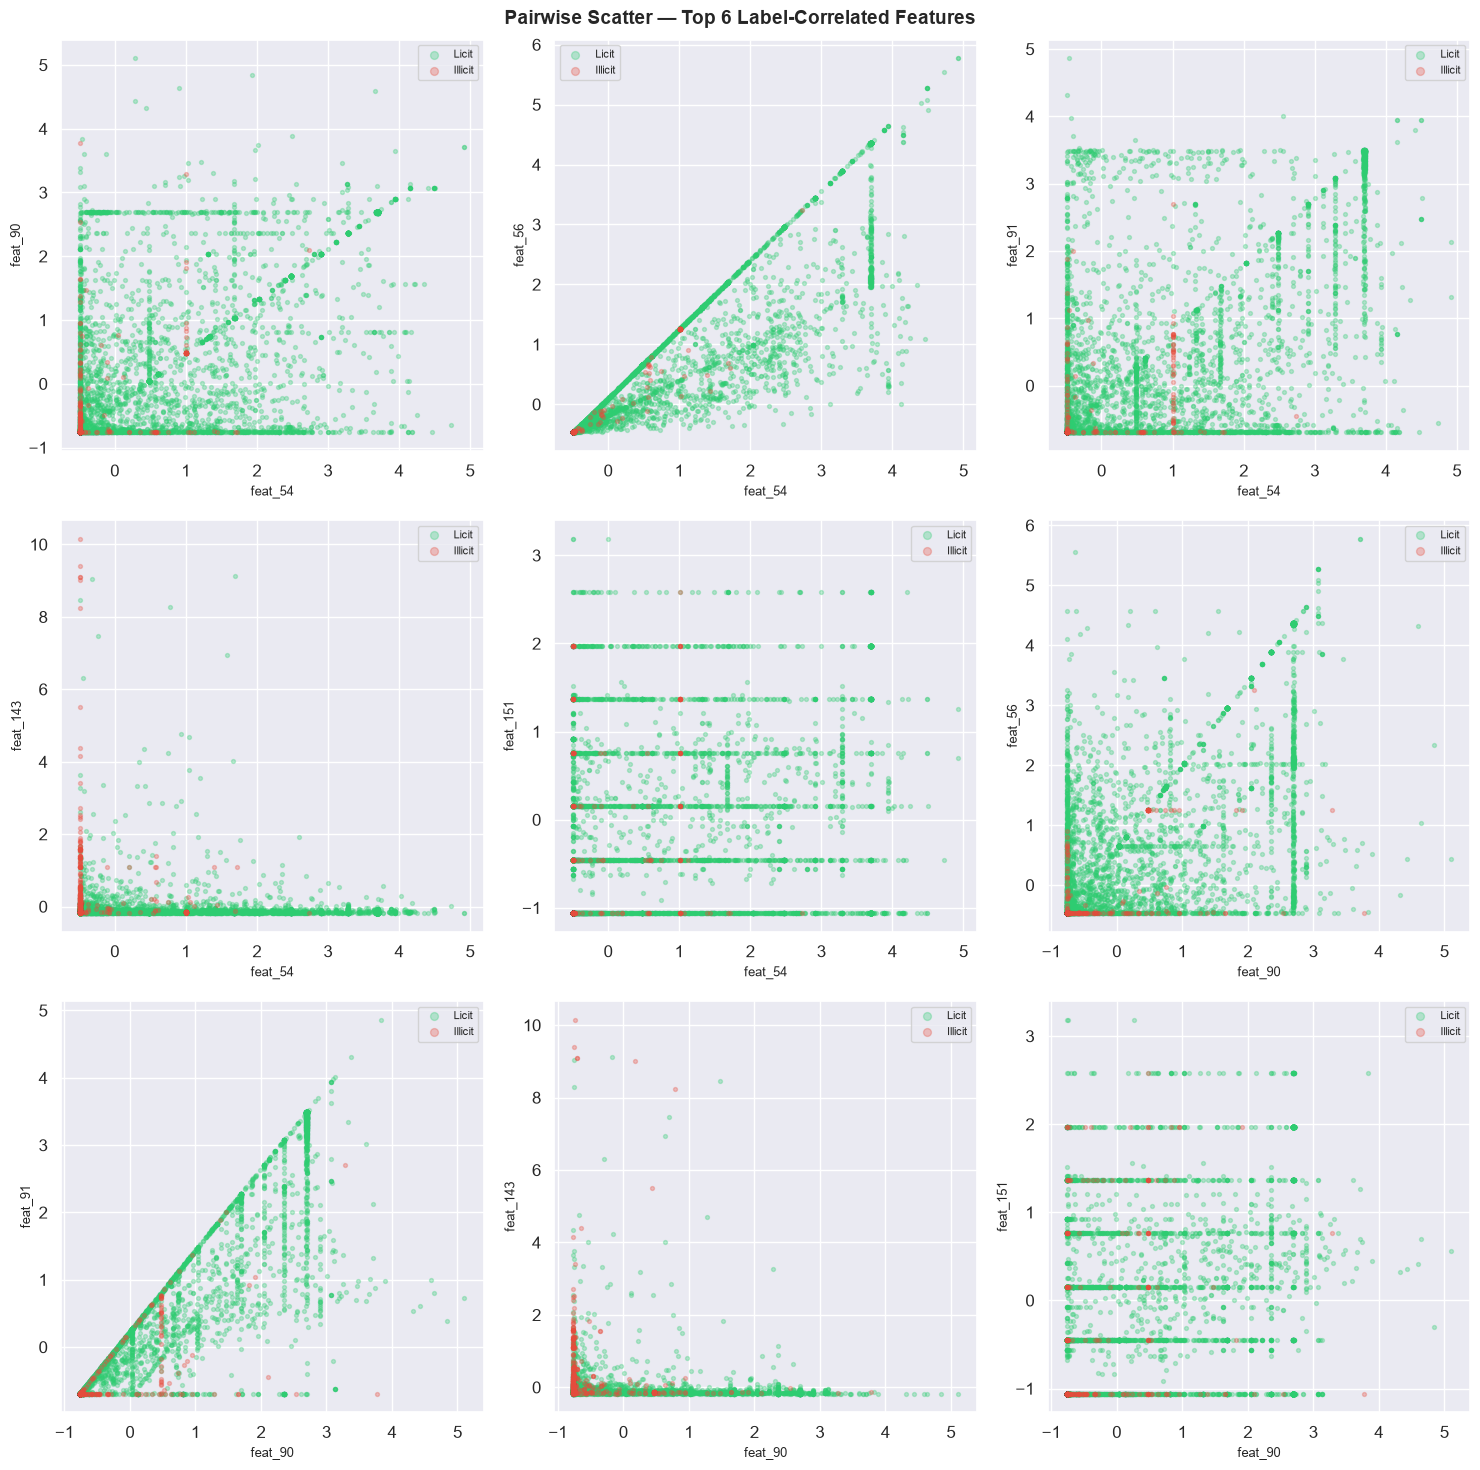

In [13]:
top6 = corr.head(6).index.tolist()
sample = labeled_df.sample(n=min(5000, len(labeled_df)), random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

pair_idx = 0
for i in range(len(top6)):
    for j in range(i + 1, len(top6)):
        if pair_idx >= 9:
            break
        ax = axes[pair_idx // 3, pair_idx % 3]
        for cls, color in [("Licit", PALETTE["Licit"]), ("Illicit", PALETTE["Illicit"])]:
            mask = sample["class_name"] == cls
            ax.scatter(sample.loc[mask, top6[i]], sample.loc[mask, top6[j]],
                       c=color, alpha=0.3, s=8, label=cls)
        ax.set_xlabel(top6[i], fontsize=9)
        ax.set_ylabel(top6[j], fontsize=9)
        ax.legend(fontsize=8, markerscale=2)
        pair_idx += 1
    if pair_idx >= 9:
        break

for k in range(pair_idx, 9):
    axes[k // 3, k % 3].set_visible(False)

fig.suptitle("Pairwise Scatter — Top 6 Label-Correlated Features",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/09_pairwise_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 14. Box Plots by Class

**What:** Side-by-side box plots for the top 10 most correlated features, grouped by class.

**Why this matters:**
- Box plots show **median, quartiles, and outliers** — more informative than just the mean
- Clearly reveals if one class has a **shifted distribution** for specific features
- Outlier points (dots beyond the whiskers) may indicate anomalous transactions

**What to look for:**
- Features where the **medians** (center lines) differ between classes → discriminative
- Features where the **boxes** don't overlap → very discriminative
- Heavy outliers in the illicit class → potential fraud patterns

/var/folders/zd/k__jg6ms0vx0hryd2kzd7c5c0000gn/T/ipykernel_2658/1460453547.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


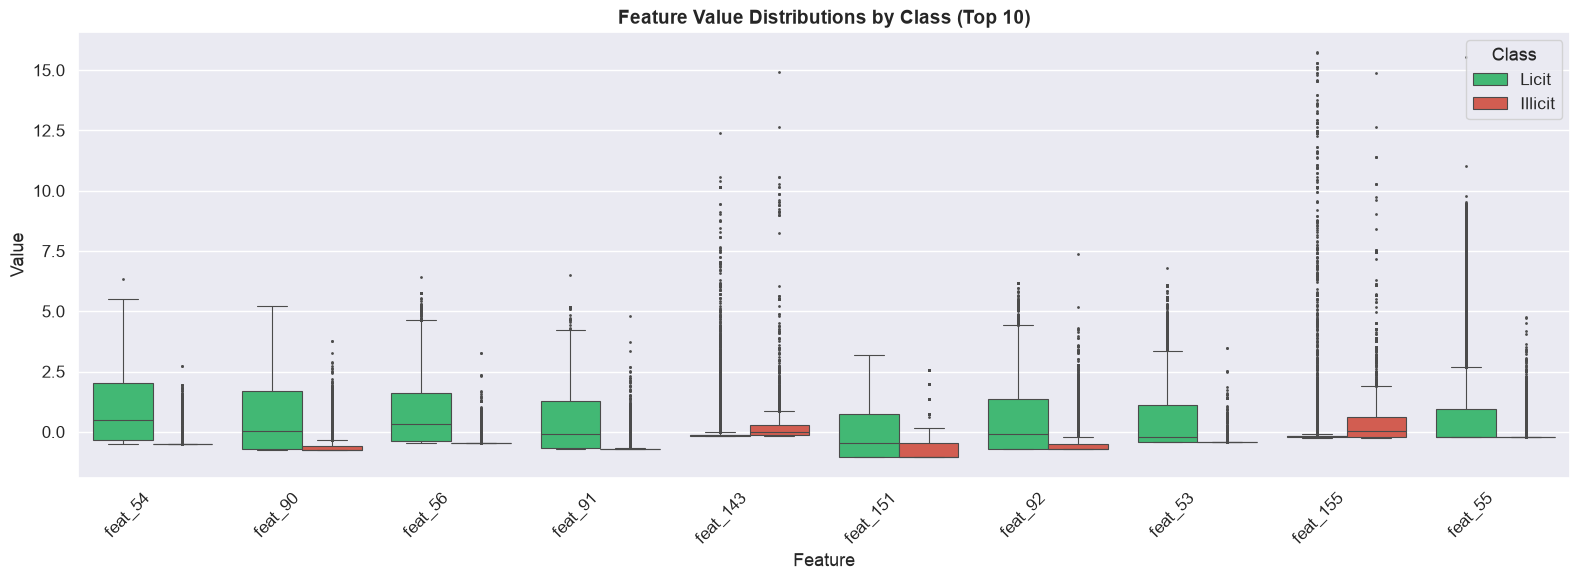

In [14]:
top10 = corr.head(10).index.tolist()
melt_df = labeled_df[top10 + ["class_name"]].melt(
    id_vars="class_name", var_name="Feature", value_name="Value"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=melt_df, x="Feature", y="Value", hue="class_name",
            palette={"Licit": PALETTE["Licit"], "Illicit": PALETTE["Illicit"]},
            fliersize=1, linewidth=0.8, ax=ax)
ax.set_title("Feature Value Distributions by Class (Top 10)", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Class")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/11_boxplots_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 15. 🧠 Key Takeaways

### Dataset Properties

| Finding | Value | Implication |
|---------|-------|-------------|
| Class imbalance | **1:9.2** (illicit:licit) | Use weighted `CrossEntropyLoss` with `weight=[1.0, 9.2]` |
| Unlabeled nodes | **77.1%** | GNNs leverage these via message passing (semi-supervised) |
| Max single-feature \|r\| | **0.26** (`feat_54`) | No single feature is strong → need feature combos + graph structure |
| Graph sparsity | **Avg degree 2.3** | 2-layer GNN is sufficient; deeper risks over-smoothing |
| Degree distribution | **Heavy-tailed**, max=473 | Use GraphSAGE with neighbor sampling for scalability |
| Temporal variation | **Fraud rate 0.3%–36%** | Use chronological train/test splits for realistic evaluation |
| Features pre-normalized | **Mean≈0, Std≈1** | Skip z-score in `graph_builder.py` |
| Aggregated features (95-166) | Higher correlation with label | Confirms neighborhood info matters → GNN advantage |

### Implications for Model Design

1. **Loss function:** Must use class-weighted loss — otherwise model will predict all-licit and get ~90% accuracy
2. **Architecture:** 2-layer GNN (GraphSAGE or GAT) is appropriate given the sparse graph
3. **Evaluation metric:** Use **F1-score** and **PR-AUC** instead of accuracy (due to imbalance)
4. **Data split:** Chronological split (by timestep) is more rigorous than random split
5. **Feature engineering:** Not needed — features are already engineered and normalized by the dataset authors

### Next Steps

1. **Phase 2** → Implement `graph_builder.py` (masks, class weights, normalization)
2. **Phase 4** → Train baseline models (LogReg, XGBoost) to set performance floor
3. **Phase 5** → Build GNN models (GraphSAGE, GAT)
4. **Phase 6** → Train, evaluate, and compare all models